c:\Users\vanes\OneDrive\Desktop\QuantumPhysicsNotebook\.venv\Lib\site-packages\qutip\core\coefficient.py:199: FutureWarning: The signature f(t, args) is deprecated and will be removed in QuTiP 5.5. Please update your function to the pythonic signature f(t, **kwargs) to maintain compatibility.
  op = FunctionCoefficient(base, args.copy(), style=function_style)


Ground state:
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]]
Excited state:
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]]
Initial qubit-resonator state:
Quantum object: dims=[[2, 10], [1]], shape=(20, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]
Qubit lowering operator: [[2, 10], [2, 10]]
Qubit Z operator: [[2, 10], [2, 10]]
Resonator operator: [[2, 10], [2, 10]]
Hamiltonian: time-dependent
Number of time points: 1000
Number of quantum states: 1000
Initial P(|1>): 0.0
Maximum P(|1>): 0.0035974610584628293
Maximum resonator photon number: 7.1548950869127665
I/Q samples: 1000
First 5 I/Q samples: [-0.03431396+0.06755079j -0.02420269-0.07562645j  0.08800283-0.06653526j
  0.12178053-0.10889839j  0.11606334-0.03497073j]
Saved I/Q data to simulated_IQ.csv
Saved binary I/Q data for

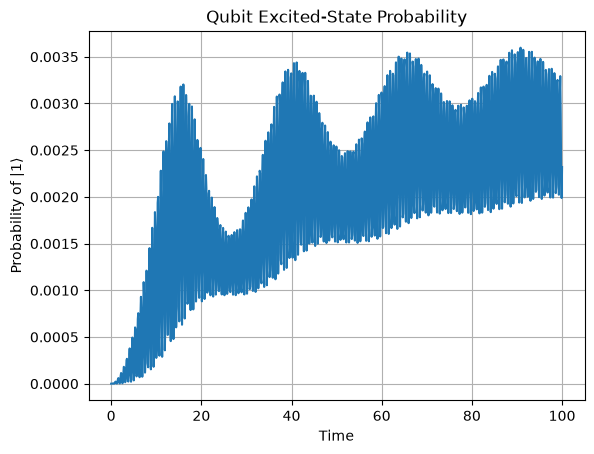

In [82]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
# Our Qubit has 2 states
ground = qt.basis(2, 0) # 2 basis states // we are in ground state 0
excited = qt.basis(2, 1)

psi0 = ground # we are starting in the ground state

# Our resonator has multiple photon-number states (10 here)
N = 10
resonator = qt.destroy(N) # annihilation operator

# Joint qubit + resonator state
psi0 = qt.tensor(ground, qt.basis(N, 0))

# Qubit operators
sm = qt.destroy(2)
sz = qt.sigmaz()

# Joint-system operators
sm_joint = qt.tensor(sm, qt.qeye(N))
sz_joint = qt.tensor(sz, qt.qeye(N))

# Resonator operator
a_joint = qt.tensor(qt.qeye(2), resonator)

# Qubit drive operator
drive_operator = sm_joint + sm_joint.dag()

# Resonator drive operator
resonator_drive = a_joint + a_joint.dag()

# System parameters
wq = 5.0       # qubit frequency
wr = 5.0       # resonator frequency
g = 0.1        # qubit-resonator coupling strength

# Microwave drive parameters
drive_amplitude = 0.5
drive_frequency = wr

# Qubit-resonator Hamiltonian
H0 = (
    0.5 * wq * sz_joint
    + wr * a_joint.dag() * a_joint
    + g * (sm_joint.dag() * a_joint + sm_joint * a_joint.dag())
)

# Microwave drive
H_drive = drive_amplitude * resonator_drive

H = [H0, [H_drive, lambda t, args: np.cos(drive_frequency * t)]]

# Time evolution
t = np.linspace(0, 100, 1000)

# Qubit relaxation
T1 = 40.0
gamma1 = 1.0 / T1

# Qubit dephasing
T2 = 30.0
gamma_phi = 1.0 / T2

# Resonator energy decay
kappa = 0.05

# Resonator collapse operator
c_resonator = np.sqrt(kappa) * a_joint

# Collapse operator for energy relaxation
c_ops = [
    np.sqrt(gamma1) * sm_joint,
    np.sqrt(gamma_phi / 2) * sz_joint,
    c_resonator
]

result = qt.mesolve(H, psi0, t, c_ops=c_ops)

# Qubit excited-state probability
P_excited = []

for state in result.states:
    rho_qubit = state.ptrace(0)
    P1 = qt.expect(excited * excited.dag(), rho_qubit)
    P_excited.append(P1)


# Resonator photon number
P_resonator = []

for state in result.states:
    n = qt.expect(a_joint.dag() * a_joint, state)
    P_resonator.append(n)

# Simulated resonator readout signal
resonator_amplitude = np.sqrt(np.array(P_resonator))

# Add measurement noise
noise_level = 0.05
noise_I = noise_level * np.random.randn(len(t))
noise_Q = noise_level * np.random.randn(len(t))

I_signal = resonator_amplitude + noise_I
Q_signal = noise_Q

# Complex I/Q signal
IQ_signal = I_signal + 1j * Q_signal

# Save simulated I/Q data for GNU Radio
iq_data = np.column_stack((I_signal, Q_signal))

np.savetxt(
    "simulated_IQ.csv",
    iq_data,
    delimiter=",",
    header="I,Q",
    comments=""
)

# Save I/Q as binary float32 for GNU Radio
iq_float32 = np.column_stack((I_signal, Q_signal)).astype(np.float32)

iq_float32.tofile("simulated_IQ_float32.bin")




print(f"Ground state:\n{ground}") # output |0> = [1 0]
print(f"Excited state:\n{excited}") # output |1> = [0 1]
print(f"Initial qubit-resonator state:\n{psi0}")
# print(f"Qubit lowering operator:\n{sm_joint}")
# print(f"Qubit Z operator:\n{sz_joint}")
# print(f"Resonator annihilation operator:\n{a_joint}")
# Check dimensions of our joint-system operators
print("Qubit lowering operator:", sm_joint.dims)
print("Qubit Z operator:", sz_joint.dims)
print("Resonator operator:", a_joint.dims)
print("Hamiltonian: time-dependent")
print("Number of time points:", len(result.times))
print("Number of quantum states:", len(result.states))
print("Initial P(|1>):", P_excited[0])
print("Maximum P(|1>):", max(P_excited))
print("Maximum resonator photon number:", max(P_resonator))
print("I/Q samples:", len(IQ_signal))
print("First 5 I/Q samples:", IQ_signal[:5])
print("Saved I/Q data to simulated_IQ.csv")
print("Saved binary I/Q data for GNU Radio")


plt.plot(t, P_excited)
plt.xlabel("Time")
plt.ylabel("Probability of |1⟩")
plt.title("Qubit Excited-State Probability")
plt.grid()
plt.show()

Readout amplitude for |0>: (-0.7051950668972692-1.1753251114954486j)
Readout amplitude for |1>: (0.7051950668972687-1.1753251114954477j)
Distance between readout states: 1.410390133794538


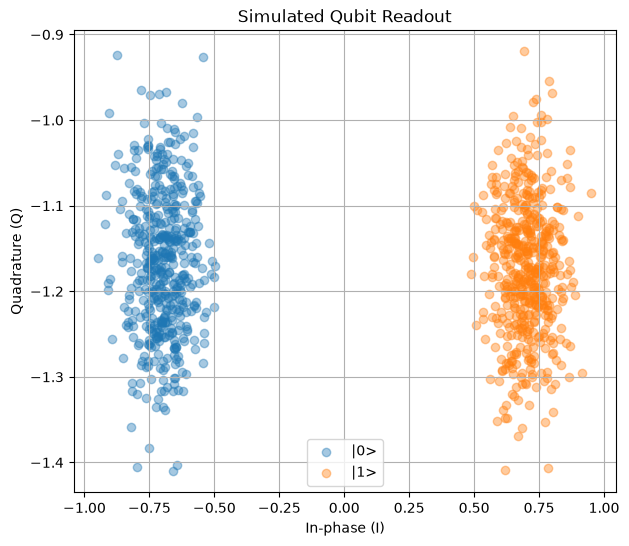


Number of shots: 1000
Saved: readout_shots_IQ.csv
Saved: readout_shots_IQ_float32.bin


In [83]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

# ==========================================
# 1. SYSTEM SIZE
# ==========================================

N = 10

# Qubit states
ground = qt.basis(2, 0)
excited = qt.basis(2, 1)

# Resonator
a = qt.destroy(N)

# Joint operators
sz = qt.tensor(qt.sigmaz(), qt.qeye(N))
a_joint = qt.tensor(qt.qeye(2), a)

n_joint = a_joint.dag() * a_joint


# ==========================================
# 2. READOUT PARAMETERS
# ==========================================

kappa = 0.5       # resonator decay
chi = 0.15        # qubit-resonator dispersive shift
drive = 0.4       # readout microwave amplitude
delta = 0.0       # resonator-drive detuning

# Dispersive readout Hamiltonian
H = (
    delta * n_joint
    + chi * sz * n_joint
    + drive * (a_joint + a_joint.dag())
)


# ==========================================
# 3. DISSIPATION
# ==========================================

c_ops = [
    np.sqrt(kappa) * a_joint
]


# ==========================================
# 4. CALCULATE |0> READOUT
# ==========================================

psi_ground = qt.tensor(ground, qt.basis(N, 0))

rho_ground = qt.steadystate(
    H,
    c_ops=c_ops
)

alpha_ground = qt.expect(a_joint, rho_ground)


# ==========================================
# 5. CALCULATE |1> READOUT
# ==========================================

psi_excited = qt.tensor(excited, qt.basis(N, 0))

# Project Hamiltonian onto excited qubit state
P_excited = qt.tensor(
    excited * excited.dag(),
    qt.qeye(N)
)

H_excited = (
    delta * n_joint
    - chi * n_joint
    + drive * (a_joint + a_joint.dag())
)

rho_excited = qt.steadystate(
    H_excited,
    c_ops=c_ops
)

alpha_excited = qt.expect(a_joint, rho_excited)


# ==========================================
# 6. PRINT CONDITIONAL READOUT STATES
# ==========================================

print("Readout amplitude for |0>:", alpha_ground)
print("Readout amplitude for |1>:", alpha_excited)

print("Distance between readout states:",
      abs(alpha_ground - alpha_excited))


# ==========================================
# 7. GENERATE NOISY READOUT SHOTS
# ==========================================

np.random.seed(42)

num_shots = 1000

noise_level = 0.08

# Randomly choose qubit state for each shot
labels = np.random.randint(0, 2, num_shots)

I = np.zeros(num_shots)
Q = np.zeros(num_shots)

for i in range(num_shots):

    if labels[i] == 0:

        signal = alpha_ground

    else:

        signal = alpha_excited

    I[i] = signal.real + noise_level * np.random.randn()
    Q[i] = signal.imag + noise_level * np.random.randn()


# Complex I/Q
IQ = I + 1j * Q


# ==========================================
# 8. SAVE DATA
# ==========================================

# CSV with labels
dataset = np.column_stack((I, Q, labels))

np.savetxt(
    "readout_shots_IQ.csv",
    dataset,
    delimiter=",",
    header="I,Q,label",
    comments=""
)

# Binary file for GNU Radio
IQ_float32 = np.column_stack((I, Q)).astype(np.float32)

IQ_float32.tofile(
    "readout_shots_IQ_float32.bin"
)


# ==========================================
# 9. DISPLAY READOUT DISTRIBUTIONS
# ==========================================

plt.figure(figsize=(7, 6))

plt.scatter(
    I[labels == 0],
    Q[labels == 0],
    alpha=0.4,
    label="|0>"
)

plt.scatter(
    I[labels == 1],
    Q[labels == 1],
    alpha=0.4,
    label="|1>"
)

plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.title("Simulated Qubit Readout")
plt.legend()
plt.grid()

plt.show()


print()
print("Number of shots:", num_shots)
print("Saved: readout_shots_IQ.csv")
print("Saved: readout_shots_IQ_float32.bin")

In [84]:
# Readout score
score = I

# Classification threshold
threshold = 0.0

predicted_labels = (score > threshold).astype(int)

# Accuracy
accuracy = np.mean(predicted_labels == labels)

print("Readout threshold:", threshold)
print("Classification accuracy:", accuracy)

Readout threshold: 0.0
Classification accuracy: 1.0


In [85]:
# ==========================================
# TEST READOUT WITH MORE NOISE
# ==========================================

noise_level = 0.5

I_noisy = np.zeros(num_shots)
Q_noisy = np.zeros(num_shots)

for i in range(num_shots):

    if labels[i] == 0:
        signal = alpha_ground
    else:
        signal = alpha_excited

    I_noisy[i] = signal.real + noise_level * np.random.randn()
    Q_noisy[i] = signal.imag + noise_level * np.random.randn()

# Threshold classifier
threshold = 0.0

predicted_labels = (I_noisy > threshold).astype(int)

accuracy = np.mean(predicted_labels == labels)

print("Noise level:", noise_level)
print("Threshold:", threshold)
print("Classification accuracy:", accuracy)

Noise level: 0.5
Threshold: 0.0
Classification accuracy: 0.927


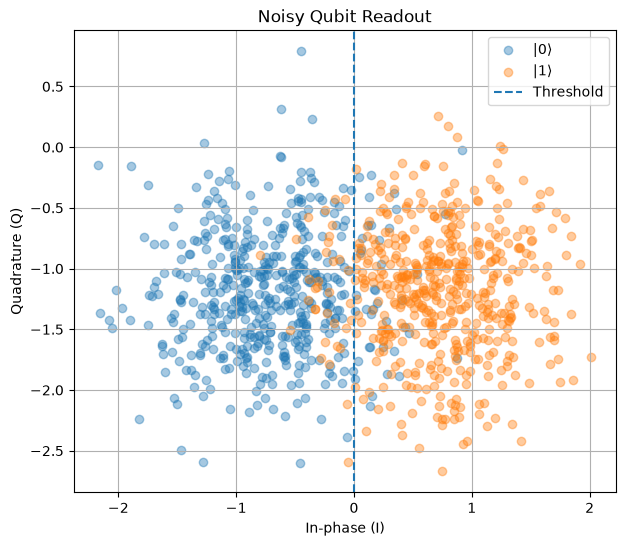

In [86]:
plt.figure(figsize=(7, 6))

plt.scatter(
    I_noisy[labels == 0],
    Q_noisy[labels == 0],
    alpha=0.4,
    label="|0⟩"
)

plt.scatter(
    I_noisy[labels == 1],
    Q_noisy[labels == 1],
    alpha=0.4,
    label="|1⟩"
)

plt.axvline(
    threshold,
    linestyle="--",
    label="Threshold"
)

plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.title("Noisy Qubit Readout")
plt.legend()
plt.grid()

plt.show()

In [87]:
# Confusion matrix using NumPy

true_0_pred_0 = np.sum((labels == 0) & (predicted_labels == 0))
true_0_pred_1 = np.sum((labels == 0) & (predicted_labels == 1))
true_1_pred_0 = np.sum((labels == 1) & (predicted_labels == 0))
true_1_pred_1 = np.sum((labels == 1) & (predicted_labels == 1))

print("Confusion Matrix:")
print([
    [true_0_pred_0, true_0_pred_1],
    [true_1_pred_0, true_1_pred_1]
])

print()
print("Correct |0>:", true_0_pred_0)
print("Incorrect |0>:", true_0_pred_1)
print("Incorrect |1>:", true_1_pred_0)
print("Correct |1>:", true_1_pred_1)

Confusion Matrix:
[[np.int64(451), np.int64(39)], [np.int64(34), np.int64(476)]]

Correct |0>: 451
Incorrect |0>: 39
Incorrect |1>: 34
Correct |1>: 476


In [88]:
# Classification metrics

precision_0 = true_0_pred_0 / (true_0_pred_0 + true_1_pred_0)
recall_0 = true_0_pred_0 / (true_0_pred_0 + true_0_pred_1)

precision_1 = true_1_pred_1 / (true_1_pred_1 + true_0_pred_1)
recall_1 = true_1_pred_1 / (true_1_pred_1 + true_1_pred_0)

f1_0 = 2 * precision_0 * recall_0 / (precision_0 + recall_0)
f1_1 = 2 * precision_1 * recall_1 / (precision_1 + recall_1)

print("---- |0> METRICS ----")
print("Precision:", precision_0)
print("Recall:", recall_0)
print("F1:", f1_0)

print()
print("---- |1> METRICS ----")
print("Precision:", precision_1)
print("Recall:", recall_1)
print("F1:", f1_1)

---- |0> METRICS ----
Precision: 0.9298969072164949
Recall: 0.9204081632653062
F1: 0.9251282051282053

---- |1> METRICS ----
Precision: 0.9242718446601942
Recall: 0.9333333333333333
F1: 0.9287804878048781


In [89]:
# ==========================================
# FIND BEST READOUT THRESHOLD
# ==========================================

thresholds = np.linspace(-1.5, 1.5, 301)

accuracies = []

for threshold_test in thresholds:

    predictions = (I_noisy > threshold_test).astype(int)

    accuracy_test = np.mean(predictions == labels)

    accuracies.append(accuracy_test)

best_index = np.argmax(accuracies)

best_threshold = thresholds[best_index]
best_accuracy = accuracies[best_index]

print("Best threshold:", best_threshold)
print("Best accuracy:", best_accuracy)

Best threshold: -0.08000000000000007
Best accuracy: 0.929


In [90]:
# ==========================================
# LOGISTIC REGRESSION CLASSIFIER
# ==========================================

# Features
X = np.column_stack((I_noisy, Q_noisy))

# Labels
y = labels

# Initialize weights
weights = np.zeros(2)
bias = 0.0

learning_rate = 0.01
epochs = 5000


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


for epoch in range(epochs):

    # Forward pass
    z = X @ weights + bias
    predictions = sigmoid(z)

    # Gradients
    error = predictions - y

    dw = (X.T @ error) / len(y)
    db = np.mean(error)

    # Update
    weights -= learning_rate * dw
    bias -= learning_rate * db


# Final predictions
probabilities = sigmoid(X @ weights + bias)
predicted_labels_ml = (probabilities >= 0.5).astype(int)

accuracy_ml = np.mean(predicted_labels_ml == y)

print("ML accuracy:", accuracy_ml)
print("Weights:", weights)
print("Bias:", bias)

ML accuracy: 0.926
Weights: [ 3.66098817 -0.01473009]
Bias: 0.008401630307209933


In [91]:
# ==========================================
# ML CONFUSION MATRIX
# ==========================================

true_0_pred_0 = np.sum((y == 0) & (predicted_labels_ml == 0))
true_0_pred_1 = np.sum((y == 0) & (predicted_labels_ml == 1))
true_1_pred_0 = np.sum((y == 1) & (predicted_labels_ml == 0))
true_1_pred_1 = np.sum((y == 1) & (predicted_labels_ml == 1))

print("ML Confusion Matrix:")
print([
    [true_0_pred_0, true_0_pred_1],
    [true_1_pred_0, true_1_pred_1]
])

print("Correct |0>:", true_0_pred_0)
print("Incorrect |0>:", true_0_pred_1)
print("Incorrect |1>:", true_1_pred_0)
print("Correct |1>:", true_1_pred_1)

ML Confusion Matrix:
[[np.int64(450), np.int64(40)], [np.int64(34), np.int64(476)]]
Correct |0>: 450
Incorrect |0>: 40
Incorrect |1>: 34
Correct |1>: 476


In [92]:
# ==========================================
# ML PRECISION, RECALL, F1
# ==========================================

# |0>
precision_0 = true_0_pred_0 / (true_0_pred_0 + true_1_pred_0)
recall_0 = true_0_pred_0 / (true_0_pred_0 + true_0_pred_1)

f1_0 = 2 * (precision_0 * recall_0) / (precision_0 + recall_0)

# |1>
precision_1 = true_1_pred_1 / (true_1_pred_1 + true_0_pred_1)
recall_1 = true_1_pred_1 / (true_1_pred_1 + true_1_pred_0)

f1_1 = 2 * (precision_1 * recall_1) / (precision_1 + recall_1)

print("|0> Precision:", precision_0)
print("|0> Recall:", recall_0)
print("|0> F1:", f1_0)

print()

print("|1> Precision:", precision_1)
print("|1> Recall:", recall_1)
print("|1> F1:", f1_1)

|0> Precision: 0.9297520661157025
|0> Recall: 0.9183673469387755
|0> F1: 0.9240246406570842

|1> Precision: 0.9224806201550387
|1> Recall: 0.9333333333333333
|1> F1: 0.9278752436647173


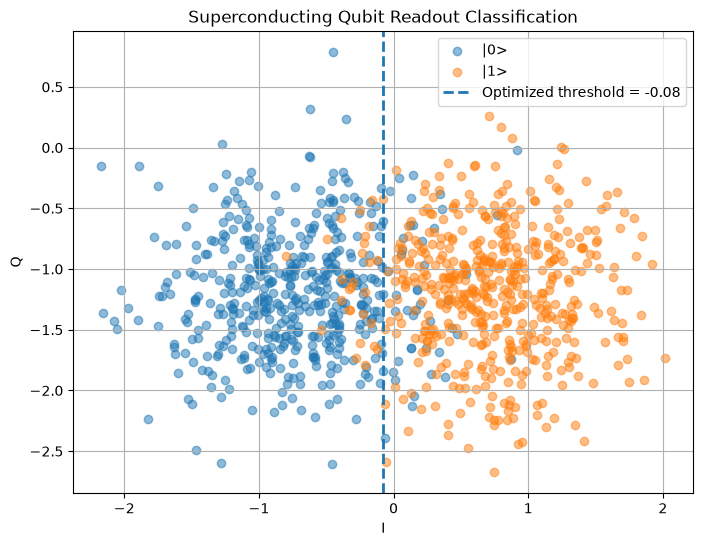

In [93]:
# ==========================================
# FINAL READOUT CLASSIFICATION PLOT
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    I_noisy[labels == 0],
    Q_noisy[labels == 0],
    alpha=0.5,
    label="|0>"
)

plt.scatter(
    I_noisy[labels == 1],
    Q_noisy[labels == 1],
    alpha=0.5,
    label="|1>"
)

# Optimized threshold
plt.axvline(
    best_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Optimized threshold = {best_threshold:.2f}"
)

plt.xlabel("I")
plt.ylabel("Q")
plt.title("Superconducting Qubit Readout Classification")
plt.legend()
plt.grid(True)

plt.show()